In [34]:
import importlib
# import own_implementation
# importlib.reload(own_implementation)

In [35]:
# from own_implementation import *
from tests import *
from generators import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
from scipy import stats
from scipy.stats import chi2_contingency, kstest 
from statsmodels.tsa.stattools import acf 
from statsmodels.sandbox.stats.runs import runstest_1samp

In [36]:
# def python_random(n):
#     return [random.random() for _ in range(n)]
#
# def PCG(n):
#     rng = np.random.default_rng()
#     return rng.uniform(0, 1, n)
#
# def system_random(n):
#     sys_random = random.SystemRandom()
#     return [sys_random.random() for _ in range(n)]


In [37]:
from generators import *
from numpy.random import Generator, PCG64, MT19937, Philox, SFC64

### Generators preparation
n = 10000

generators = {
    "LCG": lambda: LCG(1664525, 1013904223, 2**32, seed=42, n=n), 
    "Python Random": lambda: python_random(n=n), ## Python's built-in random module (Mersenne Twister)
    "PCG": lambda: numpy_random(n=n),   ## Numpy's default random module (PCG64),
    "Philox": lambda: numpy_random(n=n, algorithm=Philox),
    "SFC64": lambda: numpy_random(n=n, algorithm=SFC64),
    "System Random": lambda: system_random(n=n)  ## System's random module (kryptographic)
}

data_samples = {name: gen() for name, gen in generators.items()}
for name, data in data_samples.items():
    print(f"{name}: wygenerowane {len(data)} liczb losowych")


LCG: wygenerowane 10000 liczb losowych
Python Random: wygenerowane 10000 liczb losowych
PCG: wygenerowane 10000 liczb losowych
Philox: wygenerowane 10000 liczb losowych
SFC64: wygenerowane 10000 liczb losowych
System Random: wygenerowane 10000 liczb losowych


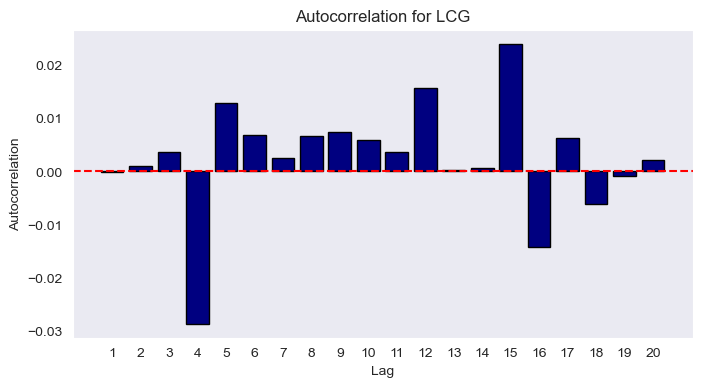

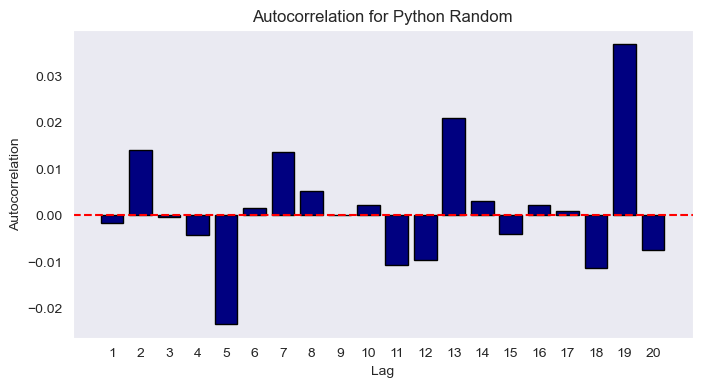

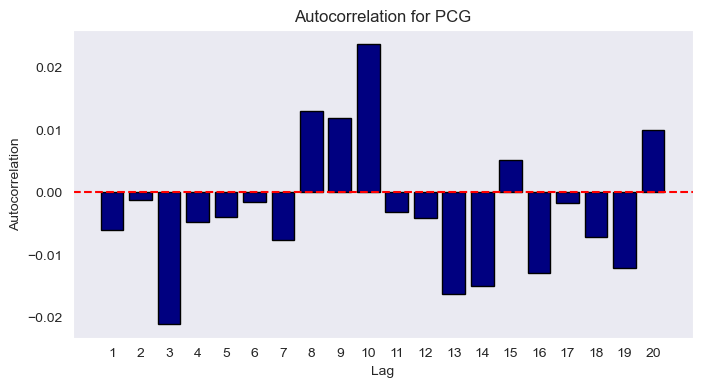

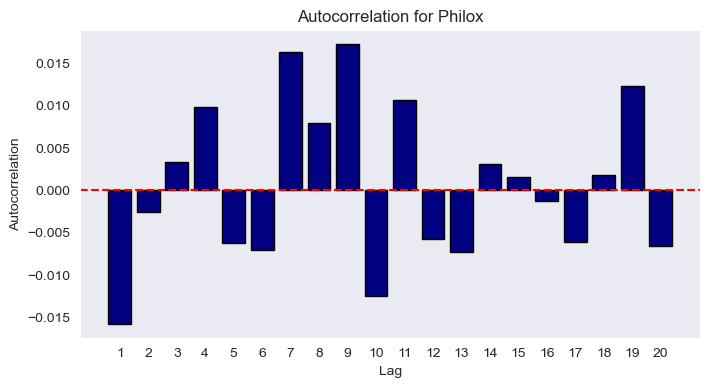

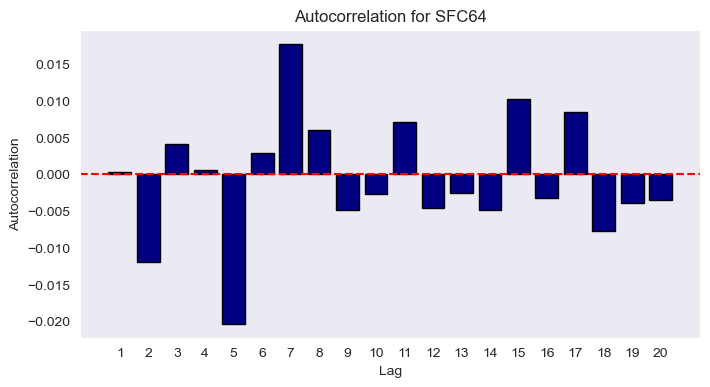

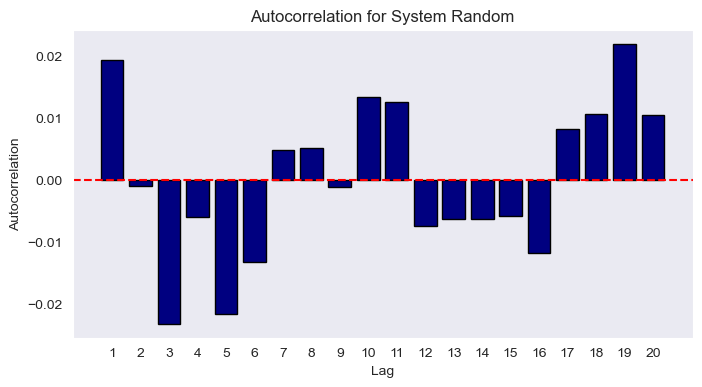

In [38]:
### Autocorrelation
max_lag = 20

for name,data in data_samples.items():
    autocorr = acf(data, nlags=max_lag, fft=True)

    plt.figure(figsize=(8, 4))
    plt.bar(range(1, max_lag+1), autocorr[1:], color='navy', edgecolor='black')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Autocorrelation for {name}')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.xticks(range(1, max_lag+1))
    plt.grid()  
    plt.show()
    

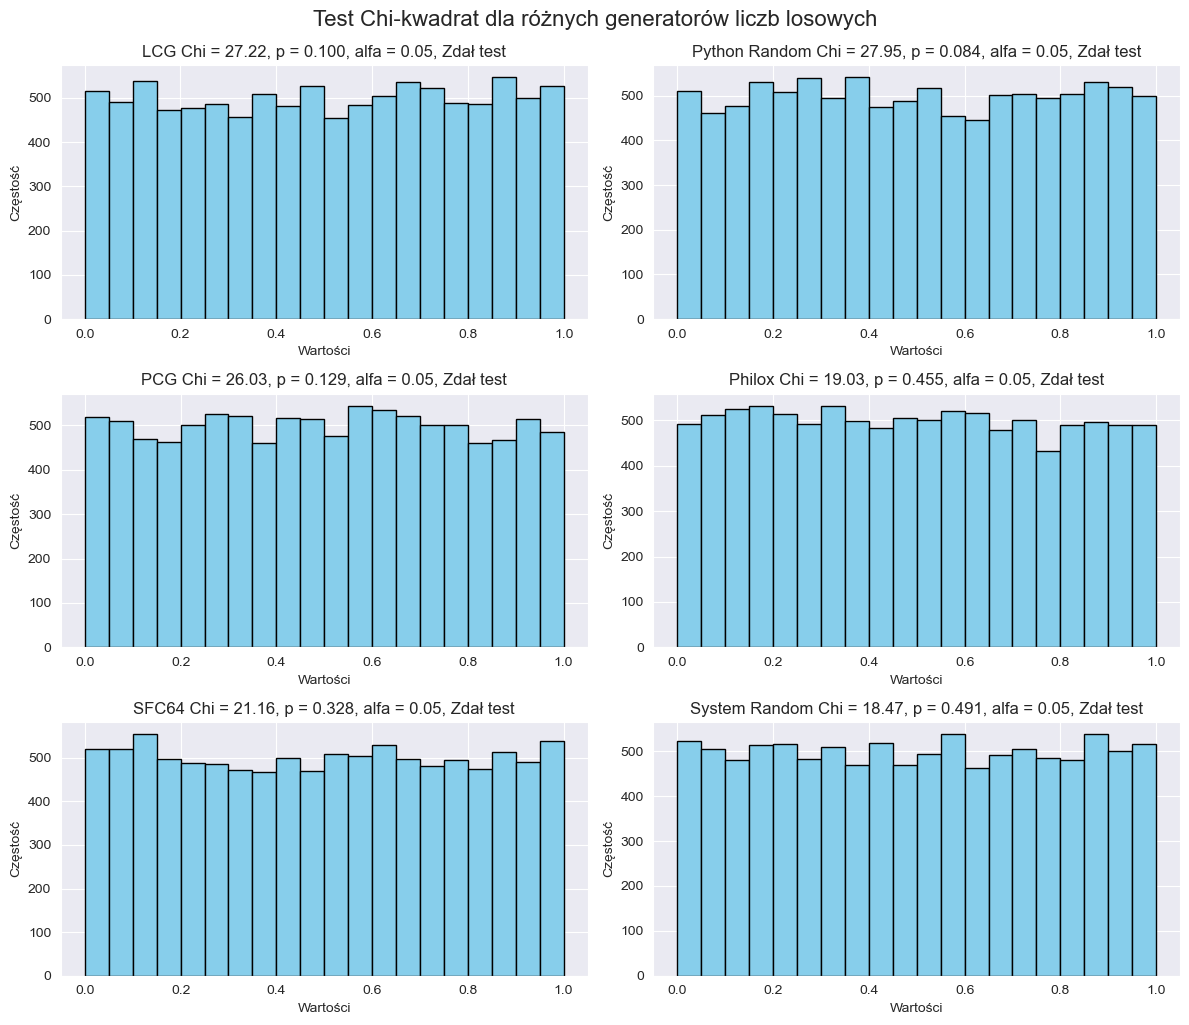

In [39]:
### Chi Square Test
bins = 20
alpha = 0.05
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(data_samples.items()):
    chi2_stat, p_val = chi_square_test(data, bins=bins)
    result = "Zdał test" if p_val > alpha else "Nie zdał testu"

    axes[idx].hist(data, bins=bins, edgecolor='black', color='skyblue')
    axes[idx].set_title(f"{name} Chi = {chi2_stat:.2f}, p = {p_val:.3f}, alfa = {alpha}, {result}")
    axes[idx].set_xlabel("Wartości")
    axes[idx].set_ylabel("Częstość")

plt.tight_layout()
plt.suptitle("Test Chi-kwadrat dla różnych generatorów liczb losowych", fontsize=16, y=1.02)
plt.show()

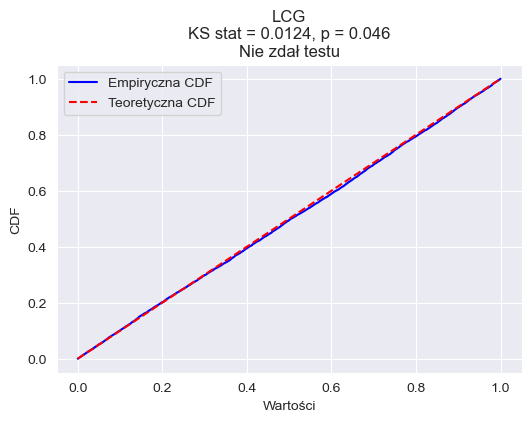

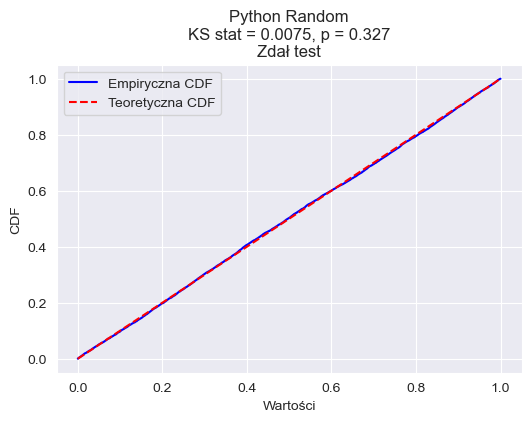

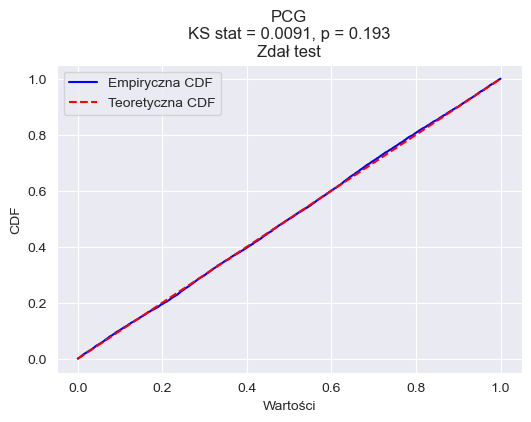

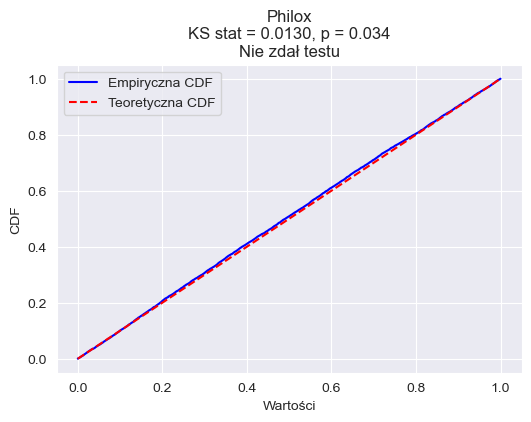

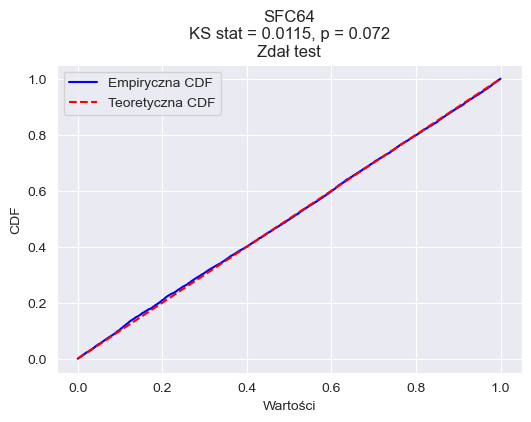

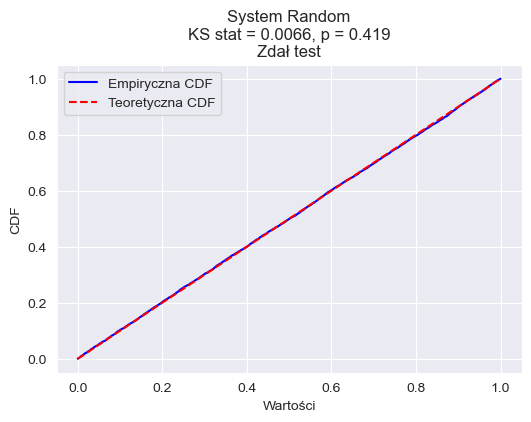

In [40]:
## Kolmogorov-Smirnov Test
alpha = 0.05

for name, data in data_samples.items():
    ks_stat, p_val = ks_test(data)
    result = "Zdał test" if p_val > alpha else "Nie zdał testu"

    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data) + 1) / len(data)
    cdf = sorted_data  

    plt.figure(figsize=(6,4))
    plt.plot(sorted_data, ecdf, label='Empiryczna CDF', color='blue')
    plt.plot(sorted_data, cdf, label='Teoretyczna CDF', linestyle='--', color='red')
    plt.title(f"{name}\nKS stat = {ks_stat:.4f}, p = {p_val:.3f}\n{result}")
    plt.xlabel("Wartości")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True)
    plt.show()


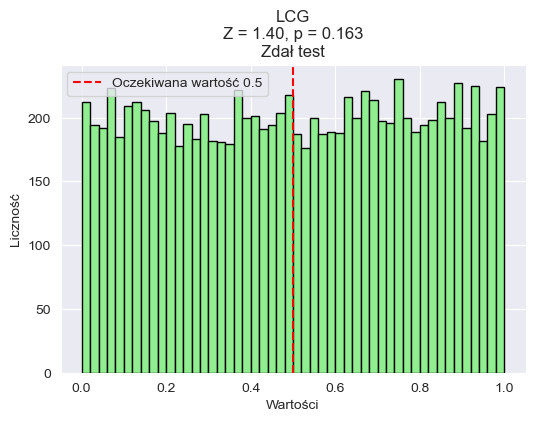

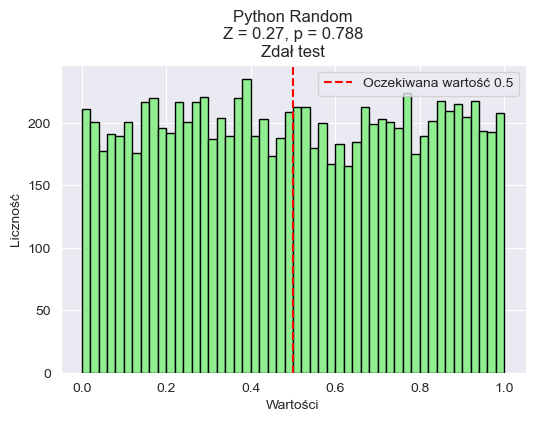

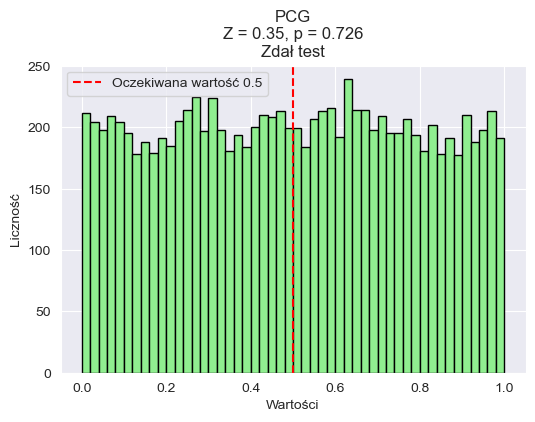

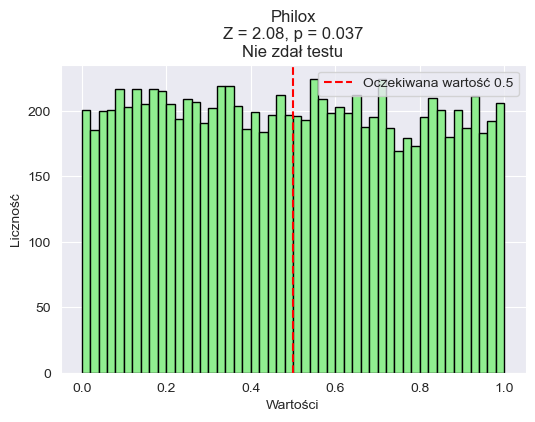

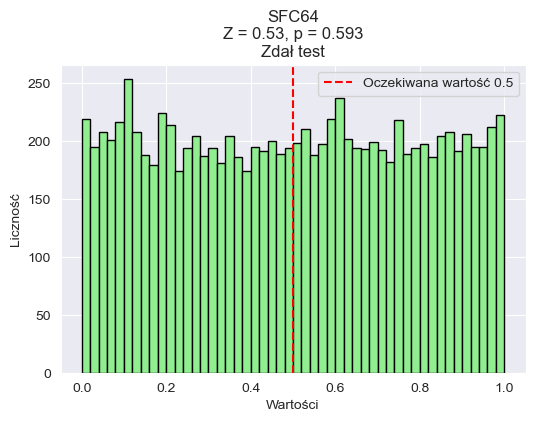

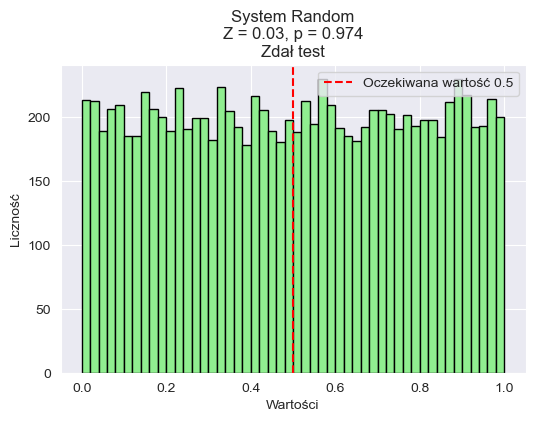

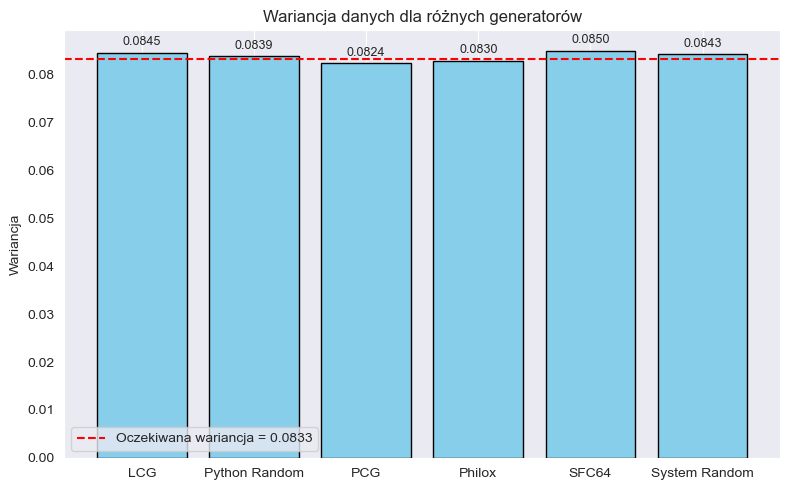

In [41]:
## Sum test
alpha = 0.05

for name,data in data_samples.items():
    z_stat, p_val = sum_test(data)
    result = "Zdał test" if p_val > alpha else "Nie zdał testu"

    plt.figure(figsize=(6,4))
    plt.hist(data, bins=50, edgecolor='black', color='lightgreen')
    plt.axvline(0.5, color='red', linestyle='--', label='Oczekiwana wartość 0.5')
    plt.title(f"{name}\nZ = {z_stat:.2f}, p = {p_val:.3f}\n{result}")
    plt.xlabel("Wartości")
    plt.ylabel("Liczność")
    plt.legend()
    plt.grid(True)
    plt.show()


expected_var = 1 / 12 

variances = {name: np.var(data) for name, data in data_samples.items()}

plt.figure(figsize=(8, 5))
bars = plt.bar(variances.keys(), variances.values(), color='skyblue', edgecolor='black')
plt.axhline(expected_var, color='red', linestyle='--', label=f"Oczekiwana wariancja = {expected_var:.4f}")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{yval:.4f}", ha='center', va='bottom', fontsize=9)

plt.title("Wariancja danych dla różnych generatorów")
plt.ylabel("Wariancja")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

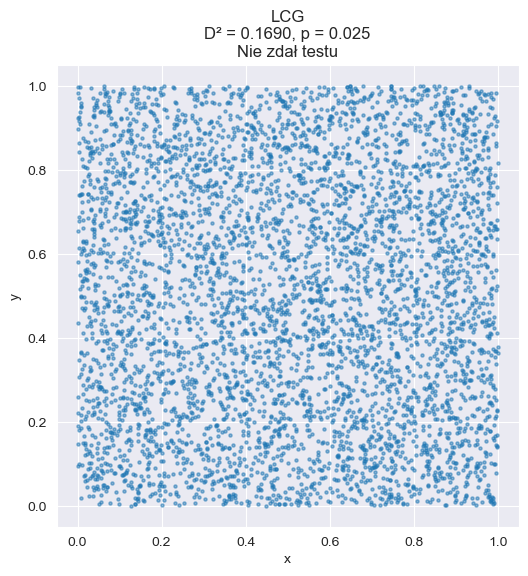

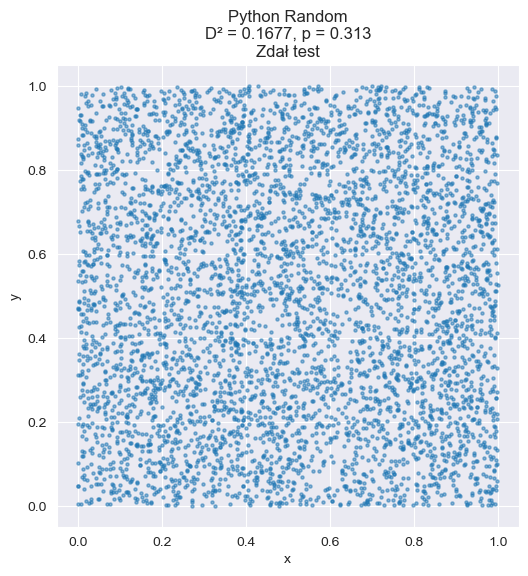

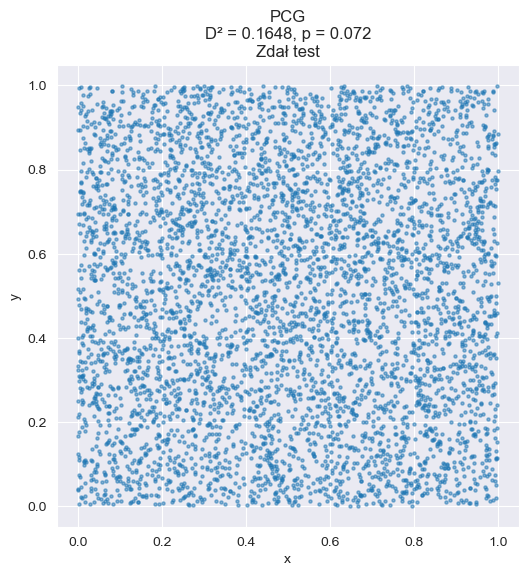

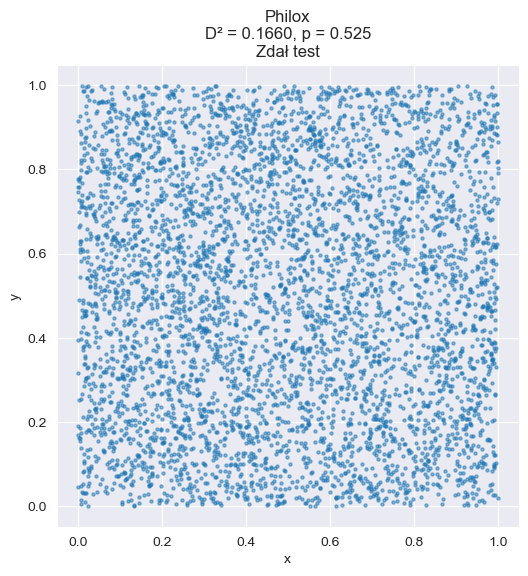

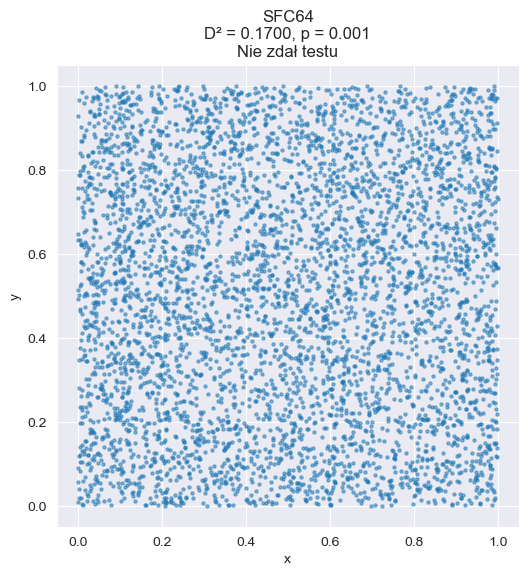

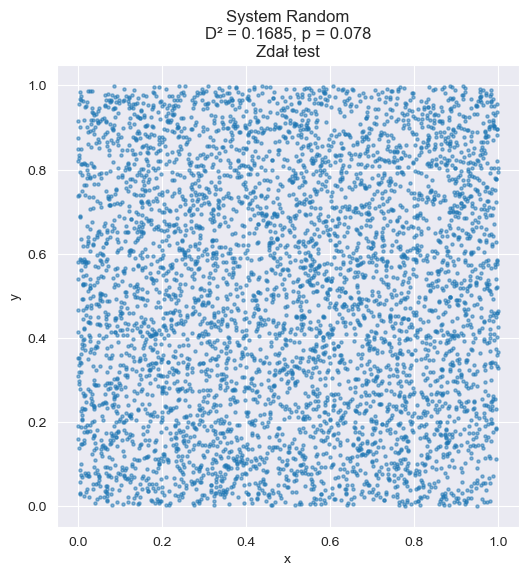

In [42]:
# D2 test
alpha = 0.05

for name, data in data_samples.items():
    d2_stat, p_val = d2_test(data)
    result = "Zdał test" if p_val > alpha else "Nie zdał testu"

    x = data[::2]
    y = data[1::2]

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, s=5, alpha=0.5)
    plt.title(f"{name}\nD² = {d2_stat:.4f}, p = {p_val:.3f}\n{result}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.gca().set_aspect('equal')
    plt.show()

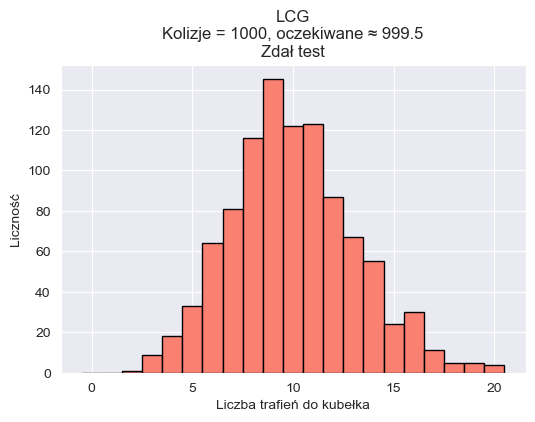

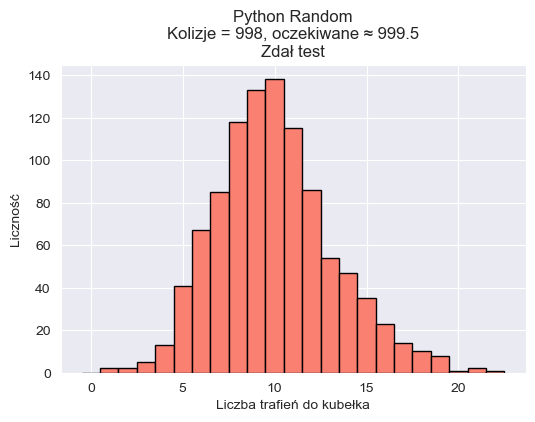

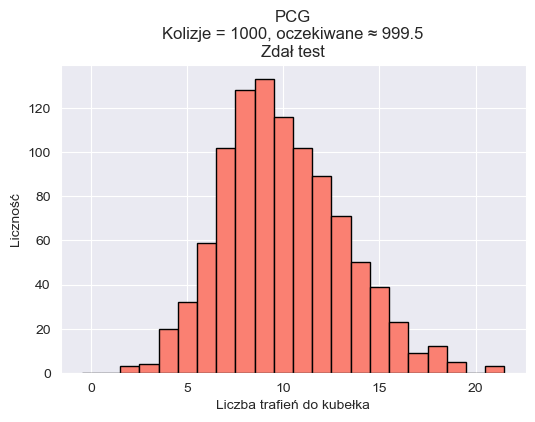

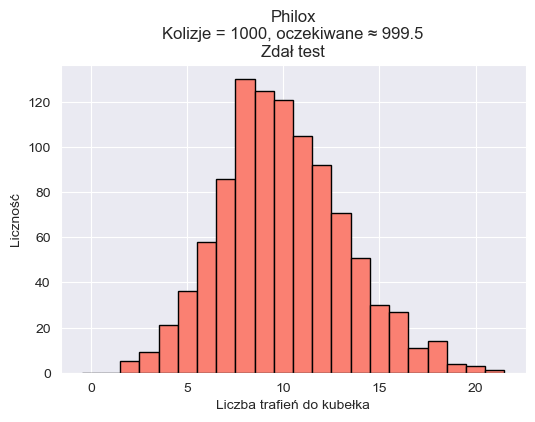

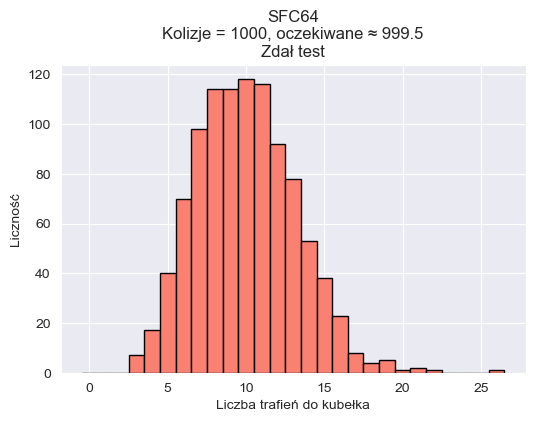

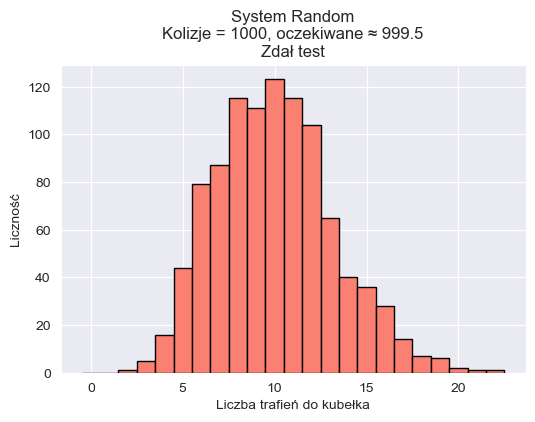

In [43]:
buckets = 1000
alpha = 0.05

for name, data in data_samples.items():
    actual_collisions, expected_collisions = collision_test(data, m=buckets)
    result = "Zdał test" if actual_collisions <= expected_collisions * 1.1 else "Nie zdał testu"

    hits = np.zeros(buckets, dtype=int)
    for x in data:
        idx = int(x * buckets)
        if idx == buckets: idx -= 1
        hits[idx] += 1

    plt.figure(figsize=(6,4))
    plt.hist(hits, bins=range(0, max(hits)+2), align='left', color='salmon', edgecolor='black')
    plt.title(f"{name}\nKolizje = {actual_collisions}, oczekiwane ≈ {expected_collisions:.1f}\n{result}")
    plt.xlabel("Liczba trafień do kubełka")
    plt.ylabel("Liczność")
    plt.grid(True)
    plt.show()

LCG: Z = -0.500, p = 0.6171 → Zdał test
Python Random: Z = 0.260, p = 0.7949 → Zdał test
PCG: Z = 0.940, p = 0.3472 → Zdał test
Philox: Z = 0.840, p = 0.4009 → Zdał test
SFC64: Z = 1.000, p = 0.3173 → Zdał test
System Random: Z = -2.160, p = 0.0308 → Nie zdał testu


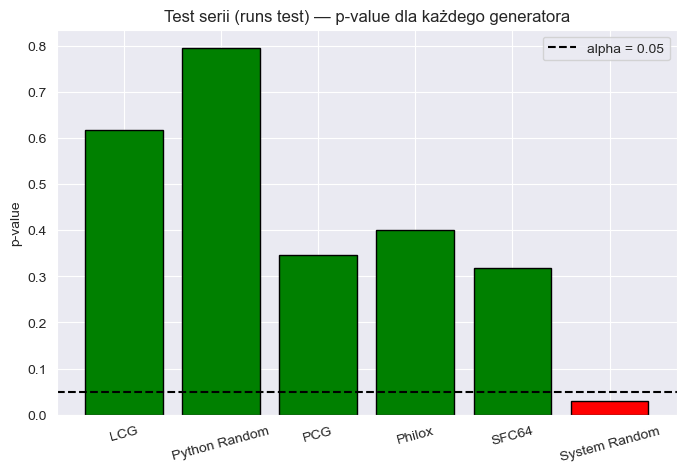

In [44]:
alpha = 0.05

results = {}

for name, data in data_samples.items():
    z_stat, p_val = runs_test(data)
    result = "Zdał test" if p_val > alpha else "Nie zdał testu"
    results[name] = {"z": z_stat, "p": p_val, "result": result}
    print(f"{name}: Z = {z_stat:.3f}, p = {p_val:.4f} → {result}")

names = list(results.keys())
pvals = [results[n]["p"] for n in names]
colors = ["green" if results[n]["p"] > alpha else "red" for n in names]

plt.figure(figsize=(8, 5))
plt.bar(names, pvals, color=colors, edgecolor='black')
plt.axhline(alpha, color='black', linestyle='--', label=f'alpha = {alpha}')
plt.title("Test serii (runs test) — p-value dla każdego generatora")
plt.ylabel("p-value")
plt.xticks(rotation=15)
plt.legend()
plt.grid(True)
plt.show()

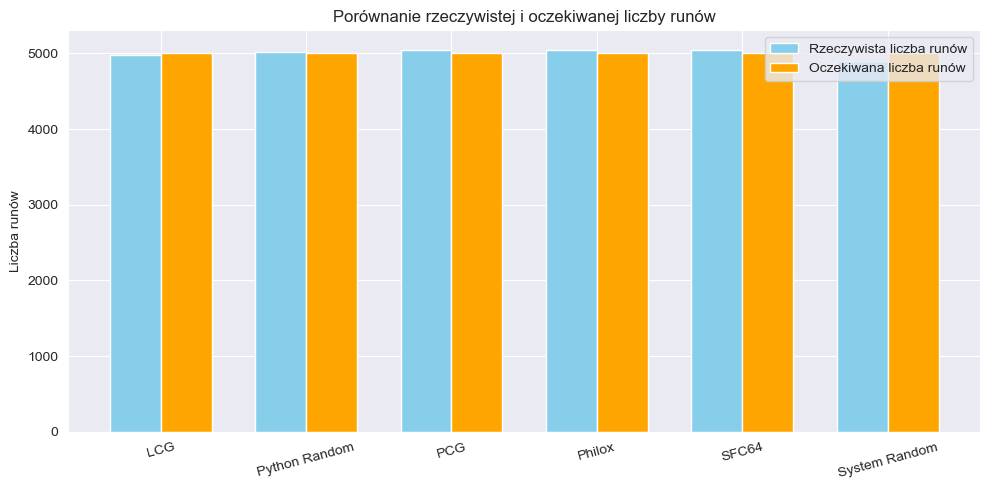

In [50]:
names = []
actual_runs = []
expected_runs = []

for name, data in data_samples.items():
    median = np.median(data)
    signs = [1 if x > median else 0 for x in data]

    runs = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1]:
            runs += 1

    n1 = float(np.sum(signs))
    n2 = float(len(signs) - n1)
    expected = ((2 * n1 * n2) / (n1 + n2)) + 1

    names.append(name)
    actual_runs.append(runs)
    expected_runs.append(expected)

# Wykres
x = np.arange(len(names))
bar_width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - bar_width/2, actual_runs, width=bar_width, label="Rzeczywista liczba runów", color='skyblue')
plt.bar(x + bar_width/2, expected_runs, width=bar_width, label="Oczekiwana liczba runów", color='orange')
plt.xticks(x, names, rotation=15)
plt.ylabel("Liczba runów")
plt.title("Porównanie rzeczywistej i oczekiwanej liczby runów")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

LCG Z = 1.001, p = 0.3170
Python Random Z = 0.887, p = 0.3749
PCG Z = 0.233, p = 0.8155
Philox Z = 0.909, p = 0.3635
SFC64 Z = 1.036, p = 0.3002
System Random Z = 0.131, p = 0.8959


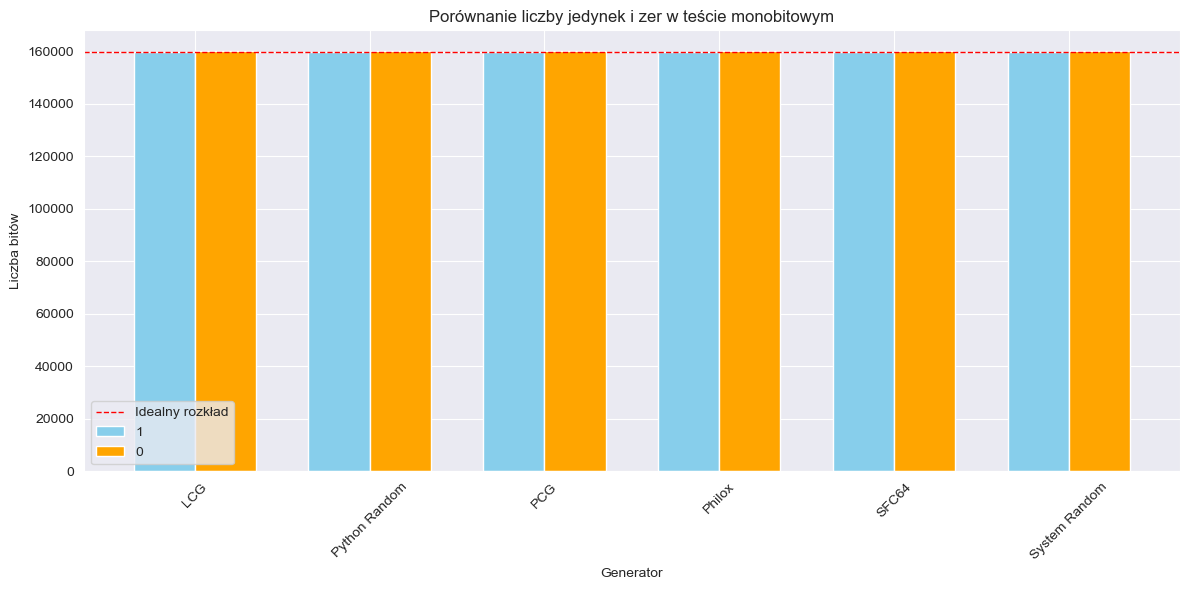

In [51]:

for name, data in data_samples.items():
    z_stat, p_val, ones, zeros = monobit_test(data)

    print(name, f"Z = {z_stat:.3f}, p = {p_val:.4f}")

plt.figure(figsize=(12, 6))
index = np.arange(len(generators))

plt.bar(index-bar_width/2, ones, bar_width, label='1', color='skyblue')
plt.bar(index+bar_width/2, zeros, bar_width, label='0', color='orange')


plt.axhline(y=160000, color='red', linestyle='--', linewidth=1, label='Idealny rozkład')

plt.xlabel('Generator')
plt.ylabel('Liczba bitów')
plt.title('Porównanie liczby jedynek i zer w teście monobitowym')
plt.xticks(index, generators, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
# assert len(lcg_numbers) == n, "Błąd: Nieprawidłowa liczba wygenerowanych liczb."
# assert all(0 <= x < 1 for x in lcg_numbers), "Błąd: Liczby nie są w zakresie (0, 1)."

# # sprawdzenie równomierności rozkładu
# max_range = 100  # liczba przedziałów dla testu chi-kwadrat
# observed, _ = np.histogram(lcg_numbers, bins=max_range, range=(0, 1))
# expected = np.full(max_range, n / max_range)
# chi2, p = stats.chisquare(observed, expected)
# print(f"Test chi-kwadrat: chi2 = {chi2:.2f}, p-value = {p:.4f}")
# assert p > 0.05, "Błąd: Rozkład nie jest równomierny (p-value < 0.05)."

In [48]:
# autocorr = np.corrcoef(lcg_numbers[:-1], lcg_numbers[1:])[0, 1]
# print(f"Autokorelacja: {autocorr:.4f}")
# assert abs(autocorr) < 0.1, "Błąd: Wysoka autokorelacja między kolejnymi liczbami."

In [49]:
# plt.figure(figsize=(12, 5))

# # histogram
# plt.subplot(1, 2, 1)
# plt.hist(lcg_numbers, bins=50, edgecolor='black')
# plt.title('Histogram rozkładu LCG')
# plt.xlabel('Wartość')
# plt.ylabel('Częstość')

# # wyk. sekwencji
# plt.subplot(1, 2, 2)
# plt.scatter(range(n), lcg_numbers, s=1)
# plt.title('Sekwencja liczb LCG')
# plt.xlabel('Indeks')
# plt.ylabel('Wartość')

# plt.tight_layout()
# plt.show()